<a href="https://colab.research.google.com/github/Shahla-AAFS/Nail_disorder_detection/blob/main/Nail_disorder_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls "/content/drive/MyDrive/main nail dataset"

Acral_Lentiginous_Melanoma  clubbing	  Onychogryphosis
blue_finger		    Healthy_Nail  pitting


In [3]:
dataset_path = "/content/drive/MyDrive/main nail dataset"

In [4]:
import os
print(os.listdir("/content/drive/MyDrive/main nail dataset"))

['Acral_Lentiginous_Melanoma', 'Onychogryphosis', 'blue_finger', 'pitting', 'clubbing', 'Healthy_Nail']


In [5]:
!pip install split-folders

In [6]:
import splitfolders

splitfolders.ratio(
    "/content/drive/MyDrive/main nail dataset",
    output="/content/nail_split",
    seed=42,
    ratio=(0.8, 0.2)   # 80% train, 20% validation
)

Copying files: 4147 files [01:21, 50.87 files/s] 


In [7]:
!ls /content/nail_split

train  val


In [8]:
!ls /content/nail_split/train

Acral_Lentiginous_Melanoma  clubbing	  Onychogryphosis
blue_finger		    Healthy_Nail  pitting


In [9]:
!ls /content/nail_split/val

Acral_Lentiginous_Melanoma  clubbing	  Onychogryphosis
blue_finger		    Healthy_Nail  pitting


In [10]:
!ls /content/drive/MyDrive/nail_split

train  val


In [11]:
!ls -lh /content/drive/MyDrive/

total 293M
-rw------- 1 root root 872K Jan 17  2023  90ae48bb7eb843bbb3397fb63ed9cd7e.pdf
-rw------- 1 root root  12K Feb 20 12:42  9HtXNLfvxe
drwx------ 2 root root 4.0K Sep 28  2025 'Colab Notebooks'
-rw------- 1 root root  176 Jun 20  2024 'Copy of All canteen time schedule.gsheet'
-rw------- 1 root root 235K Apr 10 06:14 'Copy of fathima-shabrun-shahla-19ca6594-9ac9-4d4c-95eb-8c9d792e526d-certificate.pdf'
-rw------- 1 root root  176 Sep 14  2025 'Copy of this is my original literature review shhet, brie....gsheet'
-rw------- 1 root root  73M Jul  3  2024 'Efficient-Task Project demo.mp4'
-rw------- 1 root root  176 Nov  9  2024 'Google Keep Document.gdoc'
-rw------- 1 root root 191K Jul  8  2021  IMG-20210530-WA0016.jpg
-rw------- 1 root root 205K Jul  8  2021  IMG-20210530-WA0018.jpg
-rw------- 1 root root 3.4M Oct 30  2023 'Lecture 10 - Cloud Computing with Microsoft AZURE.pdf'
-rw------- 1 root root 5.6M Oct 30  2023 'Lecture 11 - Microsoft Reports and Create a Setup File.pdf'
-

In [ ]:
!cp -rv /content/nail_split /content/drive/MyDrive/

In [12]:
#check if the splitted folders are exist inside drive
import os

base_path = "/content/drive/MyDrive/nail_split"
print("Train classes:", os.listdir(os.path.join(base_path, "train")))
print("Validation classes:", os.listdir(os.path.join(base_path, "val")))

Train classes: ['Acral_Lentiginous_Melanoma', 'Onychogryphosis', 'blue_finger', 'pitting', 'clubbing', 'Healthy_Nail']
Validation classes: ['Acral_Lentiginous_Melanoma', 'Onychogryphosis', 'blue_finger', 'pitting', 'clubbing', 'Healthy_Nail']


In [13]:
#Install  import all libraries

import os, gc, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score
)

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices('GPU'))

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
# Global config
# ───────────────────────────
CFG = {
    "base_path"      : "/content/drive/MyDrive/nail_split",
    "save_dir"       : "/content/drive/MyDrive/nail_models",
    "img_size"       : (224, 224),
    "batch_size"     : 16,
    "num_classes"    : 6,
    "seed"           : 42,
    "phase1_epochs"  : 10,
    "phase2_epochs"  : 20,
    "phase1_lr"      : 1e-3,
    "phase2_lr"      : 1e-5,
    "unfreeze_layers": 30,
    "dropout_rate"   : 0.4,
    "dense_units"    : 256,
    "class_names"    : [
        'Acral_Lentiginous_Melanoma',
        'Healthy_Nail',
        'Onychogryphosis',
        'blue_finger',
        'clubbing',
        'pitting'
    ]
}

TRAIN_DIR = os.path.join(CFG["base_path"], "train")
VAL_DIR   = os.path.join(CFG["base_path"], "val")
os.makedirs(CFG["save_dir"], exist_ok=True)

print("Train dir :", TRAIN_DIR, "| exists:", os.path.exists(TRAIN_DIR))
print("Val   dir :", VAL_DIR,   "| exists:", os.path.exists(VAL_DIR))
print("Save  dir :", CFG["save_dir"])

Train dir : /content/drive/MyDrive/nail_split/train | exists: True
Val   dir : /content/drive/MyDrive/nail_split/val | exists: True
Save  dir : /content/drive/MyDrive/nail_models


In [15]:
# Build shared data generators (run ONCE, reused by all 3 models)
# ──────────────────────────────────────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale            = 1.0 / 255,
    horizontal_flip    = True,
    rotation_range     = 15,
    zoom_range         = 0.2,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    brightness_range   = [0.8, 1.2],
    fill_mode          = 'nearest'
)
val_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = CFG["img_size"],
    batch_size  = CFG["batch_size"],
    class_mode  = 'categorical',
    shuffle     = True,
    seed        = CFG["seed"]
)
val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size = CFG["img_size"],
    batch_size  = CFG["batch_size"],
    class_mode  = 'categorical',
    shuffle     = False
)

print("Class index mapping :", train_gen.class_indices)
print("Train batches       :", len(train_gen))
print("Val   batches       :", len(val_gen))

Found 3316 images belonging to 6 classes.
Found 831 images belonging to 6 classes.
Class index mapping : {'Acral_Lentiginous_Melanoma': 0, 'Healthy_Nail': 1, 'Onychogryphosis': 2, 'blue_finger': 3, 'clubbing': 4, 'pitting': 5}
Train batches       : 208
Val   batches       : 52


In [19]:
 #Calculate class weights                              ║
# ║  Run ONCE after generators. Reused by all 3 models.            ║
# ╚══════════════════════════════════════════════════════════════════╝

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# ── Step 1: Get all training labels ───────────────────────────────
# train_gen.classes gives integer label for every training image
train_labels = train_gen.classes   # e.g. [0, 0, 1, 2, 2, 3, ...]

# ── Step 2: Count images per class ────────────────────────────────
unique_classes, counts = np.unique(train_labels, return_counts=True)

print("="*55)
print("  Class distribution in TRAINING set")
print("="*55)
print(f"  {'Class':<35} {'Count':>6}  {'%':>6}")
print("-"*55)
total_train = len(train_labels)
for cls_idx, count in zip(unique_classes, counts):
    cls_name = CFG["class_names"][cls_idx]
    pct      = count / total_train * 100
    print(f"  {cls_name:<35} {count:>6}  {pct:>5.1f}%")
print("-"*55)
print(f"  {'TOTAL':<35} {total_train:>6}  100.0%")

# ── Step 3: Check imbalance ratio ─────────────────────────────────
max_count = counts.max()
min_count = counts.min()
imbalance_ratio = max_count / min_count
print(f"\n  Max class count : {max_count}")
print(f"  Min class count : {min_count}")
print(f"  Imbalance ratio : {imbalance_ratio:.2f}x")

if imbalance_ratio > 1.5:
    print("\n  WARNING: Imbalance ratio > 1.5 — class weights are important!")
else:
    print("\n  Classes are relatively balanced — weights still help slightly.")

# ── Step 4: Compute class weights using sklearn ───────────────────
# Formula: weight[i] = total_samples / (n_classes * count[i])
# Minority classes get HIGHER weights → model pays more attention to them
class_weights_array = compute_class_weight(
    class_weight = 'balanced',
    classes      = unique_classes,
    y            = train_labels
)

# Convert to dict format required by Keras model.fit()
class_weight_dict = {
    int(cls_idx): float(weight)
    for cls_idx, weight in zip(unique_classes, class_weights_array)
}

print("\n" + "="*55)
print("  Computed class weights (for model.fit)")
print("="*55)
print(f"  {'Class':<35} {'Weight':>8}")
print("-"*55)
for cls_idx, weight in class_weight_dict.items():
    cls_name = CFG["class_names"][cls_idx]
    print(f"  {cls_name:<35} {weight:>8.4f}")
print("="*55)
print("\n  Higher weight = model penalises mistakes on this class more.")
print("  class_weight_dict is ready. Use it in all 3 model.fit() calls.")

  Class distribution in TRAINING set
  Class                                Count       %
-------------------------------------------------------
  Acral_Lentiginous_Melanoma             604   18.2%
  Healthy_Nail                           522   15.7%
  Onychogryphosis                        551   16.6%
  blue_finger                            489   14.7%
  clubbing                               626   18.9%
  pitting                                524   15.8%
-------------------------------------------------------
  TOTAL                                 3316  100.0%

  Max class count : 626
  Min class count : 489
  Imbalance ratio : 1.28x

  Classes are relatively balanced — weights still help slightly.

  Computed class weights (for model.fit)
  Class                                 Weight
-------------------------------------------------------
  Acral_Lentiginous_Melanoma            0.9150
  Healthy_Nail                          1.0587
  Onychogryphosis                       1.0030


In [20]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Define ALL shared functions                           ║
# ║  THIS CELL MUST RUN BEFORE ANY MODEL CELL                      ║
# ║  build_model / get_callbacks / plot_history /                  ║
# ║  plot_confusion_matrix / evaluate_model / evaluate_ensemble    ║
# ╚══════════════════════════════════════════════════════════════════╝

# ── Function 1: build any model by name ───────────────────────────
def build_model(model_name, cfg):
    """
    Builds transfer learning model with frozen backbone + custom head.
    model_name: 'mobilenetv2' | 'resnet50' | 'efficientnetb0'
    Returns (model, backbone)
    """
    img_shape = (*cfg["img_size"], 3)

    if model_name == 'mobilenetv2':
        backbone   = tf.keras.applications.MobileNetV2(
            input_shape=img_shape, include_top=False, weights='imagenet')
        preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

    elif model_name == 'resnet50':
        backbone   = tf.keras.applications.ResNet50(
            input_shape=img_shape, include_top=False, weights='imagenet')
        preprocess = tf.keras.applications.resnet50.preprocess_input

    elif model_name == 'efficientnetb0':
        backbone   = tf.keras.applications.EfficientNetB0(
            input_shape=img_shape, include_top=False, weights='imagenet')
        preprocess = tf.keras.applications.efficientnet.preprocess_input

    else:
        raise ValueError(f"Unknown model: {model_name}")

    backbone.trainable = False  # Phase 1: all backbone layers frozen

    inputs  = keras.Input(shape=img_shape, name="input_image")
    x       = preprocess(inputs * 255.0)          # restore [0,255] for preprocess_input
    x       = backbone(x, training=False)          # training=False keeps BatchNorm frozen
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(cfg["dense_units"], activation='relu')(x)
    x       = layers.Dropout(cfg["dropout_rate"])(x)
    outputs = layers.Dense(cfg["num_classes"], activation='softmax')(x)

    model = keras.Model(inputs, outputs, name=f"{model_name}_model")
    return model, backbone


# ── Function 2: callbacks factory ─────────────────────────────────
def get_callbacks(model_name, phase, cfg):
    """Returns fresh callbacks for each model + phase. Saves best weights."""
    save_path = os.path.join(
        cfg["save_dir"], f"{model_name}_phase{phase}_best.keras"
    )
    return [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=5,
            restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=save_path, monitor='val_accuracy',
            save_best_only=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-7, verbose=1
        )
    ]


# ── Function 3: training history plot ─────────────────────────────
def plot_training_history(h1, h2, model_name, cfg):
    """Combines Phase1 + Phase2 history and plots accuracy & loss curves."""
    acc      = h1.history['accuracy']     + h2.history['accuracy']
    val_acc  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss     = h1.history['loss']         + h2.history['loss']
    val_loss = h1.history['val_loss']     + h2.history['val_loss']
    epochs   = range(1, len(acc) + 1)
    p1_end   = len(h1.history['accuracy'])  # mark where fine-tuning started

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'{model_name} — Training History', fontsize=13, fontweight='bold')

    for ax, tr, vl, title in [
        (ax1, acc,  val_acc,  'Accuracy'),
        (ax2, loss, val_loss, 'Loss')
    ]:
        ax.plot(epochs, tr, label=f'Train {title.lower()}')
        ax.plot(epochs, vl, label=f'Val {title.lower()}')
        ax.axvline(p1_end, color='gray', linestyle='--',
                   linewidth=0.9, label='Fine-tune start')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=8)

    plt.tight_layout()
    path = os.path.join(cfg["save_dir"], f"{model_name}_history.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  History saved → {path}")


# ── Function 4: confusion matrix plot ─────────────────────────────
def plot_confusion_matrix(y_true, y_pred, model_name, cfg):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=cfg["class_names"],
                yticklabels=cfg["class_names"], ax=ax)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True',      fontsize=11)
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
    plt.xticks(rotation=30, ha='right', fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    path = os.path.join(cfg["save_dir"], f"{model_name}_confusion_matrix.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Confusion matrix saved → {path}")


# ── Function 5: full model evaluation ─────────────────────────────
def evaluate_model(model, model_name, val_gen, cfg):
    """
    Predicts on val_gen, computes all metrics, prints report,
    plots confusion matrix. Returns dict including y_proba for ensemble.
    """
    val_gen.reset()
    y_true  = val_gen.classes
    val_gen.reset()
    y_proba = model.predict(val_gen, verbose=1)
    y_pred  = np.argmax(y_proba, axis=1)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred,        average='weighted', zero_division=0)
    try:
        auc = roc_auc_score(
            tf.keras.utils.to_categorical(y_true, cfg["num_classes"]),
            y_proba, multi_class='ovr', average='weighted'
        )
    except Exception:
        auc = float('nan')

    print(f"\n{'='*55}")
    print(f"  {model_name} — Validation Results")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {prec*100:.2f}%")
    print(f"  Recall    : {rec*100:.2f}%")
    print(f"  F1 Score  : {f1*100:.2f}%")
    print(f"  AUC-ROC   : {auc:.4f}")
    print(f"\n  Per-class report:")
    print(classification_report(y_true, y_pred,
          target_names=cfg["class_names"], zero_division=0))

    plot_confusion_matrix(y_true, y_pred, model_name, cfg)

    return {"model_name": model_name, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "auc": auc,
            "y_proba": y_proba, "y_pred": y_pred}


# ── Function 6: ensemble evaluation ───────────────────────────────
def evaluate_ensemble(y_true, y_proba, y_pred, label, cfg):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred,        average='weighted', zero_division=0)
    try:
        auc = roc_auc_score(
            tf.keras.utils.to_categorical(y_true, cfg["num_classes"]),
            y_proba, multi_class='ovr', average='weighted'
        )
    except Exception:
        auc = float('nan')

    print(f"\n{'='*55}")
    print(f"  {label} — Validation Results")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {prec*100:.2f}%")
    print(f"  Recall    : {rec*100:.2f}%")
    print(f"  F1 Score  : {f1*100:.2f}%")
    print(f"  AUC-ROC   : {auc:.4f}")
    print(classification_report(y_true, y_pred,
          target_names=cfg["class_names"], zero_division=0))
    plot_confusion_matrix(y_true, y_pred, label, cfg)

    return {"model_name": label, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "auc": auc}


print("=" * 55)
print("  All shared functions defined successfully.")
print("  You can now run the model cells below.")
print("=" * 55)



  All shared functions defined successfully.
  You can now run the model cells below.


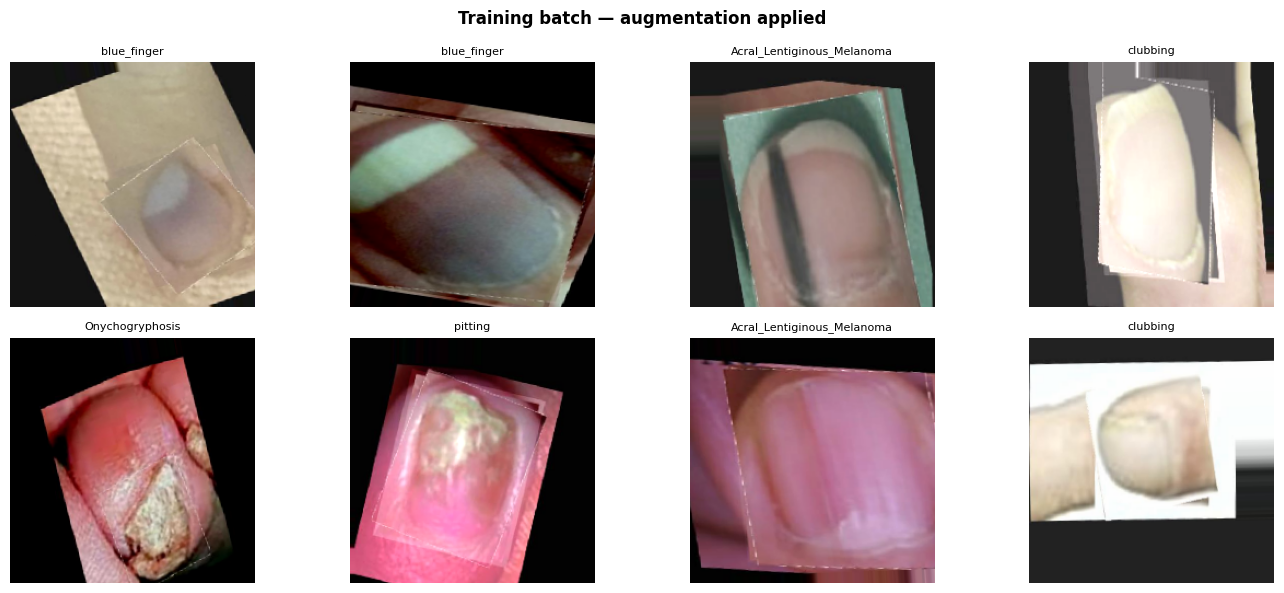

In [21]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Verify sample batch (optional visual check)           ║
# ╚══════════════════════════════════════════════════════════════════╝
images, labels    = next(train_gen)
class_idx_inv     = {v: k for k, v in train_gen.class_indices.items()}
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("Training batch — augmentation applied", fontsize=12, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i >= len(images):
        ax.axis('off'); continue
    ax.imshow(np.clip(images[i], 0, 1))
    ax.set_title(class_idx_inv[np.argmax(labels[i])], fontsize=8)
    ax.axis('off')
plt.tight_layout(); plt.show()

In [22]:
# ════════════════════════════════════════════════════════════════════
#  MODEL 1 — MobileNetV2
#  Complete cycle: Build → Phase1 → Phase2 → Evaluate → Save → Clear
# ════════════════════════════════════════════════════════════════════

# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Build MobileNetV2                                     ║
# ╚══════════════════════════════════════════════════════════════════╝
mob_model, mob_backbone = build_model('mobilenetv2', CFG)
mob_model.summary(line_length=80)
print(f"\nBackbone total layers : {len(mob_backbone.layers)}")
print(f"Layers unfrozen in Phase 2 : last {CFG['unfreeze_layers']}")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)          │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ multiply (Multiply)               │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ true_divide (TrueDivide)          │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ subtract (Subtract)               │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224 (Functional) │ (None, 7, 7, 1280)       │     2,257,984 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 1280)             │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 256)              │       327,936 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 6)                │         1,542 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Backbone total layers : 154
Layers unfrozen in Phase 2 : last 30


In [25]:
# ── CELL 8 (updated) — MobileNetV2 Phase 1 ────────────────────────

mob_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=CFG["phase1_lr"]),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
print("=== MobileNetV2 — Phase 1 (head only, backbone frozen) ===")
mob_h1 = mob_model.fit(
    train_gen,
    epochs          = CFG["phase1_epochs"],
    validation_data = val_gen,
    callbacks       = get_callbacks('mobilenetv2', phase=1, cfg=CFG),
    class_weight    = class_weight_dict,
    verbose         = 1
)


=== MobileNetV2 — Phase 1 (head only, backbone frozen) ===
Epoch 1/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5348 - loss: 1.2579
Epoch 1: val_accuracy improved from None to 0.76895, saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase1_best.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 1440s 7s/step - accuracy: 0.6378 - loss: 0.9474 - val_accuracy: 0.7690 - val_loss: 0.6441 - learning_rate: 0.0010
Epoch 2/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.7439 - loss: 0.6862
Epoch 2: val_accuracy improved from 0.76895 to 0.82190, saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase1_best.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 65s 311ms/step - accuracy: 0.7554 - loss: 0.6457 - val_accuracy: 0.8219 - val_loss: 0.5068 - learning_rate: 0.0010
Epoch 3/10

In [26]:
# ── CELL 9 (updated) — MobileNetV2 Phase 2 ────────────────────────

mob_backbone.trainable = True
for layer in mob_backbone.layers[: -CFG["unfreeze_layers"]]:
    layer.trainable = False

mob_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=CFG["phase2_lr"]),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
print("=== MobileNetV2 — Phase 2 (fine-tuning top 30 layers) ===")
mob_h2 = mob_model.fit(
    train_gen,
    epochs          = CFG["phase2_epochs"],
    validation_data = val_gen,
    callbacks       = get_callbacks('mobilenetv2', phase=2, cfg=CFG),
    class_weight    = class_weight_dict,
    verbose         = 1
)


=== MobileNetV2 — Phase 2 (fine-tuning top 30 layers) ===
Epoch 1/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.5803 - loss: 1.4775
Epoch 1: val_accuracy improved from None to 0.82912, saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 103s 394ms/step - accuracy: 0.6535 - loss: 1.1296 - val_accuracy: 0.8291 - val_loss: 0.5111 - learning_rate: 1.0000e-05
Epoch 2/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.7768 - loss: 0.6008
Epoch 2: val_accuracy improved from 0.82912 to 0.83875, saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/nail_models/mobilenetv2_phase2_best.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 64s 310ms/step - accuracy: 0.7796 - loss: 0.5830 - val_accuracy: 0.8387 - val_loss: 0.4779 - learning_rate: 1.0000e-0

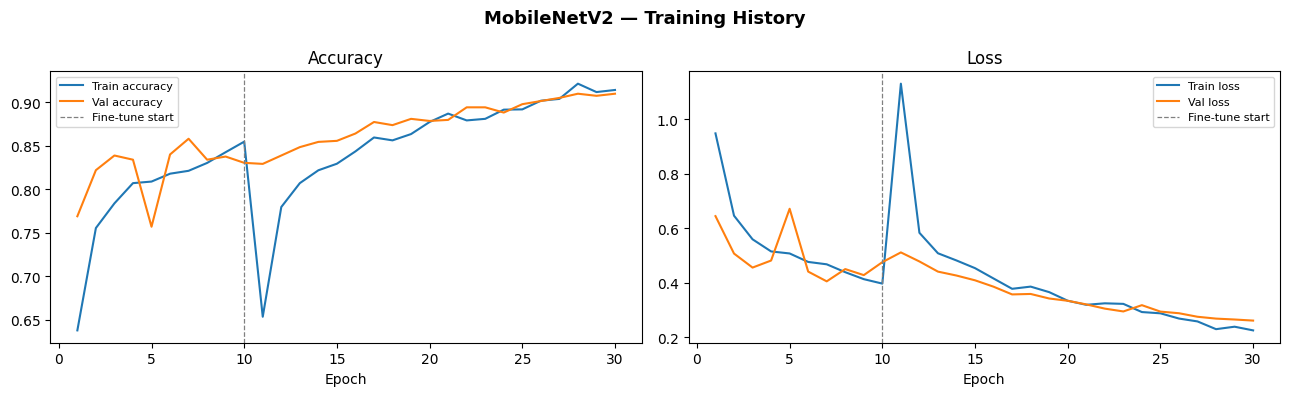

  History saved → /content/drive/MyDrive/nail_models/MobileNetV2_history.png
52/52 ━━━━━━━━━━━━━━━━━━━━ 25s 213ms/step

  MobileNetV2 — Validation Results
  Accuracy  : 90.97%
  Precision : 91.74%
  Recall    : 90.97%
  F1 Score  : 91.16%
  AUC-ROC   : 0.9926

  Per-class report:
                            precision    recall  f1-score   support

Acral_Lentiginous_Melanoma       0.89      0.88      0.89       151
              Healthy_Nail       0.99      0.98      0.98       131
           Onychogryphosis       0.97      0.91      0.94       138
               blue_finger       0.74      0.92      0.82       123
                  clubbing       0.93      0.86      0.89       157
                   pitting       0.97      0.93      0.95       131

                  accuracy                           0.91       831
                 macro avg       0.92      0.91      0.91       831
              weighted avg       0.92      0.91      0.91       831



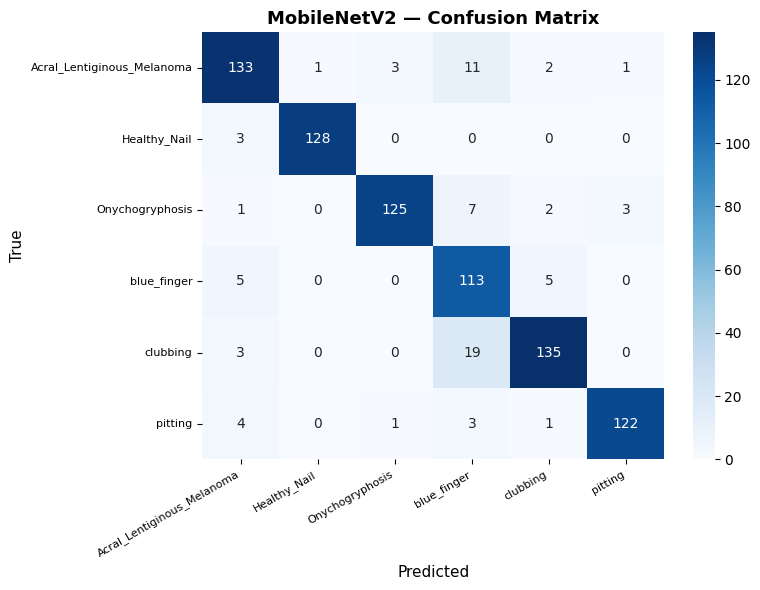

  Confusion matrix saved → /content/drive/MyDrive/nail_models/MobileNetV2_confusion_matrix.png

MobileNetV2 fully complete.
Val Accuracy : 90.97%
Val F1 Score : 91.16%

GPU memory cleared. Ready to build ResNet50.


In [27]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — MobileNetV2  Plot + Evaluate + Save + Clear GPU      ║
# ╚══════════════════════════════════════════════════════════════════╝
# Plot
plot_training_history(mob_h1, mob_h2, 'MobileNetV2', CFG)

# Evaluate — stores results AND softmax probs for ensemble
mob_results = evaluate_model(mob_model, 'MobileNetV2', val_gen, CFG)
mob_proba   = mob_results["y_proba"]   # ← keep this for ensemble at the end

# Save model to Drive
mob_model.save(os.path.join(CFG["save_dir"], "mobilenetv2_final.keras"))

# Save metrics to JSON (safe even if Colab disconnects later)
_m = {k: v for k, v in mob_results.items() if k not in ('y_proba', 'y_pred')}
with open(os.path.join(CFG["save_dir"], "mobilenetv2_metrics.json"), 'w') as f:
    json.dump(_m, f, indent=2)

print(f"\nMobileNetV2 fully complete.")
print(f"Val Accuracy : {mob_results['accuracy']*100:.2f}%")
print(f"Val F1 Score : {mob_results['f1']*100:.2f}%")

# Free GPU memory before loading next model
del mob_model, mob_backbone
gc.collect()
tf.keras.backend.clear_session()
print("\nGPU memory cleared. Ready to build ResNet50.")


# ════════════════════════════════════════════════════════════════════
#  MODEL 2 — ResNet50
#  Complete cycle: Build → Phase1 → Phase2 → Evaluate → Save → Clear
# ═════════

In [28]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — Build ResNet50                                       ║
# ╚══════════════════════════════════════════════════════════════════╝
res_model, res_backbone = build_model('resnet50', CFG)
res_model.summary(line_length=80)
print(f"\nBackbone total layers : {len(res_backbone.layers)}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "resnet50_model"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_image           │ (None, 224, 224,  │           0 │ -                  │
│ (InputLayer)          │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ multiply (Multiply)   │ (None, 224, 224,  │           0 │ input_image[0][0]  │
│                       │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ get_item (GetItem)    │ (None, 224, 224)  │           0 │ multiply[0][0]     │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ get_item_1 (GetItem)  │ (None, 224, 224)  │           0 │ multiply[0][0]     │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ get_item_2 (GetItem)  │ (None, 224, 224)  │           0 │ multiply[0][0]     │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ stack (Stack)         │ (None, 224, 224,  │           0 │ get_item[0][0],    │
│                       │ 3)                │             │ get_item_1[0][0],  │
│                       │                   │             │ get_item_2[0][0]   │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ add (Add)             │ (None, 224, 224,  │           0 │ stack[0][0]        │
│                       │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ resnet50 (Functional) │ (None, 7, 7,      │  23,587,712 │ add[0][0]          │
│                       │ 2048)             │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ global_average_pooli… │ (None, 2048)      │           0 │ resnet50[0][0]     │
│ (GlobalAveragePoolin… │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense (Dense)         │ (None, 256)       │     524,544 │ global_average_po… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout (Dropout)     │ (None, 256)       │           0 │ dense[0][0]        │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_1 (Dense)       │ (None, 6)         │       1,542 │ dropout[0][0]      │
└───────────────────────┴───────────────────┴─────────────┴────────────────────┘

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Backbone total layers : 175


In [29]:
# ── CELL 12 (updated) — ResNet50 Phase 1 ──────────────────────────

res_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=CFG["phase1_lr"]),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
print("=== ResNet50 — Phase 1 (head only, backbone frozen) ===")
res_h1 = res_model.fit(
    train_gen,
    epochs          = CFG["phase1_epochs"],
    validation_data = val_gen,
    callbacks       = get_callbacks('resnet50', phase=1, cfg=CFG),
    class_weight    = class_weight_dict,
    verbose         = 1
)


=== ResNet50 — Phase 1 (head only, backbone frozen) ===
Epoch 1/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.5424 - loss: 1.3230
Epoch 1: val_accuracy improved from None to 0.77256, saving model to /content/drive/MyDrive/nail_models/resnet50_phase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/nail_models/resnet50_phase1_best.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 105s 432ms/step - accuracy: 0.6589 - loss: 0.9195 - val_accuracy: 0.7726 - val_loss: 0.5941 - learning_rate: 0.0010
Epoch 2/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.7620 - loss: 0.6397
Epoch 2: val_accuracy improved from 0.77256 to 0.84597, saving model to /content/drive/MyDrive/nail_models/resnet50_phase1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/nail_models/resnet50_phase1_best.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 68s 327ms/step - accuracy: 0.7756 - loss: 0.5777 - val_accuracy: 0.8460 - val_loss: 0.4168 - learning_rate: 0.0010
Epoch 3/10
208/208 ━

In [31]:
# ── CELL 13 (updated) — ResNet50 Phase 2 ──────────────────────────

res_backbone.trainable = True
for layer in res_backbone.layers[: -CFG["unfreeze_layers"]]:
    layer.trainable = False

res_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=CFG["phase2_lr"]),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
print("=== ResNet50 — Phase 2 (fine-tuning top 30 layers) ===")
res_h2 = res_model.fit(
    train_gen,
    epochs          = CFG["phase2_epochs"],
    validation_data = val_gen,
    callbacks       = get_callbacks('resnet50', phase=2, cfg=CFG),
    class_weight    = class_weight_dict,
    verbose         = 1
)


=== ResNet50 — Phase 2 (fine-tuning top 30 layers) ===
Epoch 1/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.9693 - loss: 0.0904
Epoch 1: val_accuracy improved from None to 0.93622, saving model to /content/drive/MyDrive/nail_models/resnet50_phase2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/nail_models/resnet50_phase2_best.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 112s 447ms/step - accuracy: 0.9710 - loss: 0.0926 - val_accuracy: 0.9362 - val_loss: 0.1570 - learning_rate: 1.0000e-05
Epoch 2/20
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9708 - loss: 0.0745
Epoch 2: val_accuracy improved from 0.93622 to 0.93863, saving model to /content/drive/MyDrive/nail_models/resnet50_phase2_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/nail_models/resnet50_phase2_best.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 79s 382ms/step - accuracy: 0.9783 - loss: 0.0649 - val_accuracy: 0.9386 - val_loss: 0.1678 - learning_rate: 1.0000e-05
Epoch 3/20
20

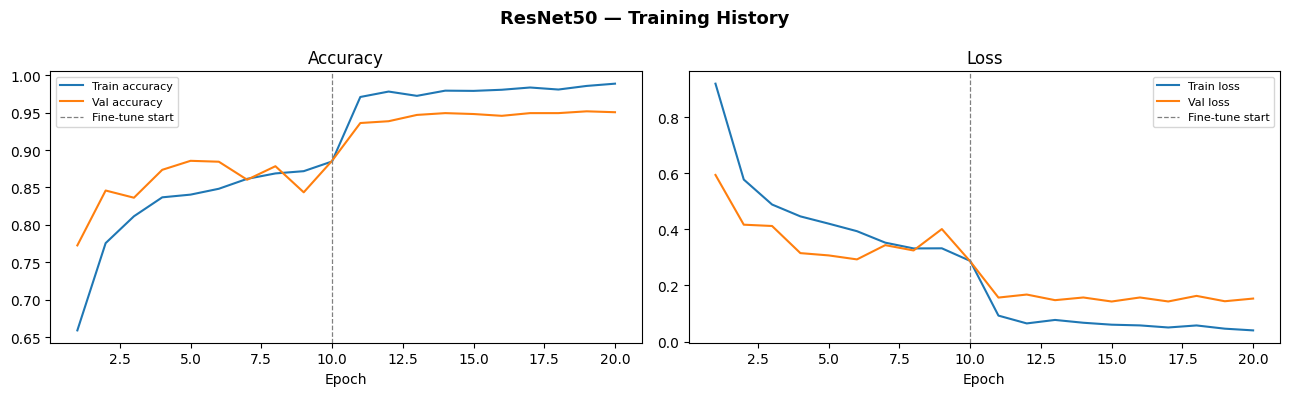

  History saved → /content/drive/MyDrive/nail_models/ResNet50_history.png
52/52 ━━━━━━━━━━━━━━━━━━━━ 21s 194ms/step

  ResNet50 — Validation Results
  Accuracy  : 94.83%
  Precision : 95.10%
  Recall    : 94.83%
  F1 Score  : 94.90%
  AUC-ROC   : 0.9978

  Per-class report:
                            precision    recall  f1-score   support

Acral_Lentiginous_Melanoma       0.93      0.95      0.94       151
              Healthy_Nail       1.00      0.99      1.00       131
           Onychogryphosis       0.99      0.95      0.97       138
               blue_finger       0.83      0.93      0.88       123
                  clubbing       0.97      0.91      0.94       157
                   pitting       0.98      0.96      0.97       131

                  accuracy                           0.95       831
                 macro avg       0.95      0.95      0.95       831
              weighted avg       0.95      0.95      0.95       831



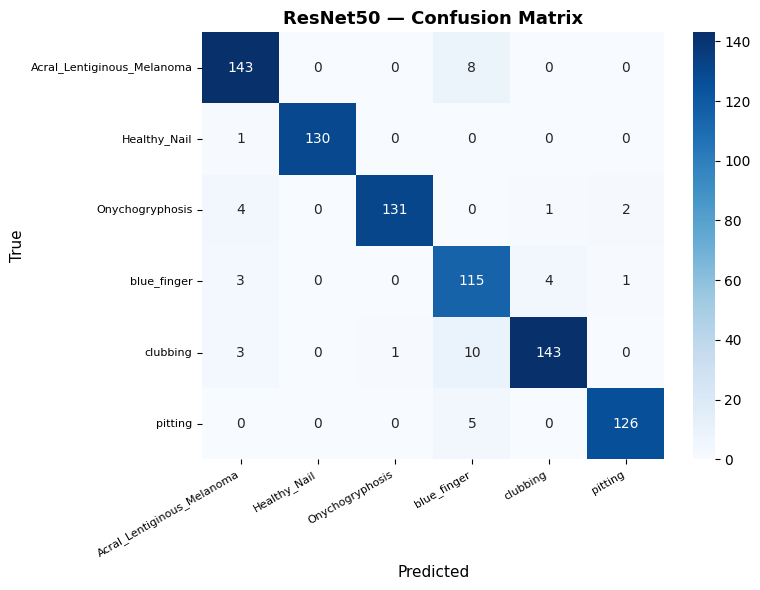

  Confusion matrix saved → /content/drive/MyDrive/nail_models/ResNet50_confusion_matrix.png

ResNet50 fully complete.
Val Accuracy : 94.83%
Val F1 Score : 94.90%

GPU memory cleared. Ready to build EfficientNetB0.


In [32]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 14 — ResNet50  Plot + Evaluate + Save + Clear GPU         ║
# ╚══════════════════════════════════════════════════════════════════╝
plot_training_history(res_h1, res_h2, 'ResNet50', CFG)

res_results = evaluate_model(res_model, 'ResNet50', val_gen, CFG)
res_proba   = res_results["y_proba"]

res_model.save(os.path.join(CFG["save_dir"], "resnet50_final.keras"))
_m = {k: v for k, v in res_results.items() if k not in ('y_proba', 'y_pred')}
with open(os.path.join(CFG["save_dir"], "resnet50_metrics.json"), 'w') as f:
    json.dump(_m, f, indent=2)

print(f"\nResNet50 fully complete.")
print(f"Val Accuracy : {res_results['accuracy']*100:.2f}%")
print(f"Val F1 Score : {res_results['f1']*100:.2f}%")

del res_model, res_backbone
gc.collect()
tf.keras.backend.clear_session()
print("\nGPU memory cleared. Ready to build EfficientNetB0.")


In [33]:
# ════════════════════════════════════════════════════════════════════
#  MODEL 3 — EfficientNetB0
#  Complete cycle: Build → Phase1 → Phase2 → Evaluate → Save → Clear
# ════════════════════════════════════════════════════════════════════

# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 15 — Build EfficientNetB0                                 ║
# ╚══════════════════════════════════════════════════════════════════╝
eff_model, eff_backbone = build_model('efficientnetb0', CFG)
eff_model.summary(line_length=80)
print(f"\nBackbone total layers : {len(eff_backbone.layers)}")


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetb0_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)          │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ multiply (Multiply)               │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)       │ (None, 7, 7, 1280)       │     4,049,571 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 1280)             │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 256)              │       327,936 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 6)                │         1,542 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)


Backbone total layers : 238


In [34]:
# ── CELL 16 (updated) — EfficientNetB0 Phase 1 ────────────────────

eff_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=CFG["phase1_lr"]),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
print("=== EfficientNetB0 — Phase 1 (head only, backbone frozen) ===")
eff_h1 = eff_model.fit(
    train_gen,
    epochs          = CFG["phase1_epochs"],
    validation_data = val_gen,
    callbacks       = get_callbacks('efficientnetb0', phase=1, cfg=CFG),
    class_weight    = class_weight_dict,
    verbose         = 1
)

=== EfficientNetB0 — Phase 1 (head only, backbone frozen) ===
Epoch 1/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.6113 - loss: 0.9702
Epoch 1: val_accuracy improved from None to 0.85560, saving model to /content/drive/MyDrive/nail_models/efficientnetb0_phase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/nail_models/efficientnetb0_phase1_best.keras
208/208 ━━━━━━━━━━━━━━━━━━━━ 127s 490ms/step - accuracy: 0.7174 - loss: 0.7351 - val_accuracy: 0.8556 - val_loss: 0.4198 - learning_rate: 0.0010
Epoch 2/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.8186 - loss: 0.4826
Epoch 2: val_accuracy did not improve from 0.85560
208/208 ━━━━━━━━━━━━━━━━━━━━ 68s 326ms/step - accuracy: 0.8215 - loss: 0.4698 - val_accuracy: 0.8544 - val_loss: 0.4137 - learning_rate: 0.0010
Epoch 3/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.8541 - loss: 0.3937
Epoch 3: val_accuracy improved from 0.85560 to 0.86282, saving model to /content/drive/MyDrive